# Heave damping calibration (alleen kwadratisch)

Dit notebook calibreert alleen de **kwadratische** heave-demping met de 40s OrcaFlex modellen.
De lineaire demping wordt NIET gekalibreerd maar vastgezet op `FIXED_LIN_HEAVE` (standaard 0.0).
Alleen de kwadratische coefficient wordt over een coarse -> mid -> fine grid gezocht.

Na het draaien kun je de gekozen kwadratische waarden handmatig overnemen in `02_calibrate_pitch_roll_damping.ipynb`.


In [1]:
# ============================================================
# NOTEBOOK 1 - Imports
# ============================================================
from pathlib import Path
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from scipy.signal import find_peaks

import OrcFxAPI


In [2]:
# ============================================================
# Paden en experimentdefinitie - HEAVE ONLY
# ============================================================
data_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata")
orca_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA")

# In dit notebook worden alleen de 40s modellen gebruikt voor heave.
# fixedwithout gebruikt hetzelfde .dat-bestand als fixedwith, maar krijgt geen deck added mass.
exp_paths = {
    "spring": {
        "heave": [
            data_root / "02" / "002" / "34224_03CB_02_002_006_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_006_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_007_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_008_01_Decay1.h5m",
        ],
    },
    "fixedwith": {
        "heave": [
            data_root / "02" / "003" / "34224_03CB_02_003_007_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_008_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_009_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_010_01_Decay1.h5m",
        ],
    },
    "fixedwithout": {
        "heave": [
            data_root / "02" / "004" / "34224_03CB_02_004_009_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_010_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_011_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_012_01_Decay1.h5m",
        ],
    },
}

# OrcaFlex modelbestanden - aerocorrected versies
model_map = {
    "spring": {
        "40s": orca_root / "Harlequin_spring_40s_aerocorrected.dat",
        "120s": orca_root / "Harlequin_spring_120s_aerocorrected.dat",
    },
    "fixedwith": {
        "40s": orca_root / "Harlequin_fixed_40s_aerocorrected.dat",
        "120s": orca_root / "Harlequin_fixed_120s_aerocorrected.dat",
    },
    "fixedwithout": {
        "40s": orca_root / "Harlequin_fixed_40s_aerocorrected.dat",
        "120s": orca_root / "Harlequin_fixed_120s_aerocorrected.dat",
    },
}

# Added mass/inertia via OrcaFlex object: aeroaddedmass
# Waarden staan expliciet op 0 als een constructie geen deck added mass heeft.
added_mass_map = {
    "spring": {
        "HydrodynamicMassZ": 21.0,
        "HydrodynamicInertiaX": 875.0,
        "HydrodynamicInertiaY": 625.0,
    },
    "fixedwith": {
        "HydrodynamicMassZ": 18.0,
        "HydrodynamicInertiaX": 0.0,
        "HydrodynamicInertiaY": 0.0,
    },
    "fixedwithout": {
        "HydrodynamicMassZ": 0.0,
        "HydrodynamicInertiaX": 0.0,
        "HydrodynamicInertiaY": 0.0,
    },
}

# Signalen in h5m
signal_map = {
    "pitch": "UnfilteredSignals/PITCH (unfiltered)",
    "roll": "UnfilteredSignals/ROLL (unfiltered)",
    "heave": "UnfilteredSignals/Z_COG (unfiltered)",
}

time_signal_map = {
    "pitch": "UnfilteredSignals/time",
    "roll": "UnfilteredSignals/time",
    "heave": "UnfilteredSignals/time",
}

sim_duration_map = {
    "pitch": 120.0,
    "roll": 120.0,
    "heave": 40.0,
}


In [3]:
# ============================================================
# NOTEBOOK 3 - Instellingen calibratie
# ============================================================
vesselname = "floaters"
vesseltypename = "floatertype"  # pas aan indien nodig

# decay start detectie
lookback_window = 1
quiet_window_end = 12.0
quiet_window_length = 50.0

# minima voor initiële amplitude
min_initial_amp = {
    "pitch": 3.0,
    "roll": 3.0,
    "heave": 0.8,   # pas aan indien nodig
}

# peak detectie
prominence_map = {
    "pitch": 0.2,
    "roll": 0.2,
    "heave": 0.002,
}

# zoekruimte
coarse_lin_values_rot = np.linspace(0, 1000, 7)
coarse_quad_values_rot  = np.linspace(0, 1000, 7)

mid_delta_lin_rot = 300
mid_delta_quad_rot = 300
mid_num_lin_rot = 7
mid_num_quad_rot = 7

fine_delta_lin_rot = 50
fine_delta_quad_rot = 50
fine_num_lin_rot = 6
fine_num_quad_rot = 6


# coarse_lin_values_rot = np.linspace(300, 300, 1)
# coarse_quad_values_rot  = np.linspace(300, 300, 1)

# mid_delta_lin_rot = 300
# mid_delta_quad_rot = 300
# mid_num_lin_rot = 1
# mid_num_quad_rot = 1

# fine_delta_lin_rot = 50
# fine_delta_quad_rot = 50
# fine_num_lin_rot = 1
# fine_num_quad_rot = 1


coarse_lin_values_heave = np.linspace(0, 6, 7)      # stap 1.0
coarse_quad_values_heave = np.linspace(2, 6, 9)     # stap 0.5
mid_delta_lin_heave = 1.5
mid_delta_quad_heave = 1.0
mid_num_lin_heave = 7
mid_num_quad_heave = 9

fine_delta_lin_heave = 0.5
fine_delta_quad_heave = 0.5
fine_num_lin_heave = 5
fine_num_quad_heave = 5

# ============================================================
# Vaste lineaire demping - ALLEEN KWADRATISCH WORDT GEKALIBREERD
# ============================================================
# De lineaire dempingscoefficient wordt niet meer meegezocht, maar
# vastgezet op onderstaande waarde. Zet hem op 0.0 voor een puur
# kwadratisch dempingsmodel, of op een eerder gekalibreerde lineaire
# waarde als je die wilt vasthouden.
FIXED_LIN_HEAVE = 0.0

# NB: de lineaire grid-instellingen (coarse_lin_values_heave, mid_delta_lin_heave,
# fine_delta_lin_heave, ...) worden niet meer gebruikt; ze blijven hieronder staan
# zodat get_grid_settings ongewijzigd kan blijven.

# output
output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_quadonly")
output_dir.mkdir(parents=True, exist_ok=True)

plots_dir = output_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

excel_path = output_dir / "calibrated_heave_decay_coefficients_quadonly.xlsx"


In [4]:
# ============================================================
# NOTEBOOK 4 - Helper functies experimentdata
# ============================================================
def read_decay_signals(exp_path: Path, dof: str):
    filtered_map = {
        "pitch": "CroppedSignals/PITCH (LPF: 5.0 rad*s^-1)",
        "roll": "CroppedSignals/ROLL (LPF: 5.0 rad*s^-1)",
        "heave": "CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)",
    }

    unfiltered_map = {
        "pitch": "UnfilteredSignals/PITCH (unfiltered)",
        "roll": "UnfilteredSignals/ROLL (unfiltered)",
        "heave": "UnfilteredSignals/Z_COG (unfiltered)",
    }

    with h5py.File(exp_path, "r") as f:
        t_filt = np.array(f["CroppedSignals/time"])
        z_filt = np.array(f[filtered_map[dof]])

        t = np.array(f["UnfilteredSignals/time"])
        z = np.array(f[unfiltered_map[dof]])

    return t_filt, z_filt, t, z

def find_first_zero_crossing(t, z):
    z = np.asarray(z)

    for i in range(1, len(z)):
        if z[i - 1] == 0:
            return i - 1, t[i - 1]
        if z[i - 1] * z[i] < 0:
            return i, t[i]

    raise ValueError("Geen zero crossing gevonden.")

def detect_decay_start(t, z, lookback_window=5.0, quiet_window_end=12.0, quiet_window_length=50.0):
    """
    Detecteer decay start als eerste tijdstip waarop het signaal duidelijk
    afwijkt van een rustige periode ervoor.
    """
    t = np.asarray(t)
    z = np.asarray(z)

    quiet_end_time = t[-1] - quiet_window_end
    quiet_start_time = quiet_end_time - quiet_window_length

    quiet_mask = (t >= quiet_start_time) & (t <= quiet_end_time)
    if np.sum(quiet_mask) < 10:
        raise ValueError("Rustige periode te klein om decay start te bepalen.")

    z_quiet = z[quiet_mask]
    mu = np.mean(z_quiet)
    sigma = np.std(z_quiet)
    threshold = max(sigma, 1e-6)

    idx_start = None
    for i in range(len(t)):
        if t[i] < t[0] + lookback_window:
            continue
        if abs(z[i] - mu) > threshold:
            idx_start = i
            break

    if idx_start is None:
        idx_start = np.argmax(np.abs(z - mu))

    return idx_start, t[idx_start], mu, sigma

def find_initial_amplitude_from_zero_crossing(t, z, t_zero, search_window=20.0):
    mask = (t >= t_zero - search_window) & (t <= t_zero)

    if np.sum(mask) == 0:
        raise ValueError("Geen data gevonden in zoekvenster voor initiële amplitude.")

    t_win = t[mask]
    z_win = z[mask]

    i_local = np.argmax(np.abs(z_win))
    return t_win[i_local], z_win[i_local]

def classify_extremum_type(a_value):
    return "peak" if a_value >= 0 else "trough"

def find_first_two_same_type_extrema_after_reference(t, z, t_reference, extremum_type, prominence):
    t = np.asarray(t)
    z = np.asarray(z)

    if extremum_type == "peak":
        idx_all, _ = find_peaks(z, prominence=prominence)
    elif extremum_type == "trough":
        idx_all, _ = find_peaks(-z, prominence=prominence)
    else:
        raise ValueError(f"Onbekend extremum_type: {extremum_type}")

    if len(idx_all) < 2:
        raise ValueError(f"Minder dan twee {extremum_type}s gevonden in signaal.")

    idx_after_ref = idx_all[t[idx_all] >= t_reference]
    if len(idx_after_ref) < 2:
        raise ValueError(
            f"Niet genoeg {extremum_type}s gevonden na referentietijd {t_reference:.3f} s."
        )

    idx_A1 = int(idx_after_ref[0])
    idx_A2 = int(idx_after_ref[1])

    return {
        "idx_A1": idx_A1,
        "t_A1": float(t[idx_A1]),
        "a_A1": float(z[idx_A1]),
        "idx_A2": idx_A2,
        "t_A2": float(t[idx_A2]),
        "a_A2": float(z[idx_A2]),
        "type": extremum_type,
    }

def prepare_experiment(exp_path: Path, dof: str):
    t_filt, z_filt, t, z = read_decay_signals(exp_path, dof)

    idx_zero, t_zero = find_first_zero_crossing(t_filt, z_filt)

    t_release_guess, a_release_guess = find_initial_amplitude_from_zero_crossing(
        t, z, t_zero, search_window=20.0
    )

    if abs(a_release_guess) < min_initial_amp[dof]:
        raise ValueError(
            f"Initiële amplitude te klein voor {dof}: {a_release_guess:.4f} "
            f"(minimum {min_initial_amp[dof]:.4f})"
        )

    extremum_type = classify_extremum_type(a_release_guess)
    ext_info = find_first_two_same_type_extrema_after_reference(
        t=t,
        z=z,
        t_reference=t_release_guess,
        extremum_type=extremum_type,
        prominence=prominence_map[dof],
    )

    mask_decay = t >= ext_info["t_A2"]
    t_decay = t[mask_decay] - ext_info["t_A2"]
    z_decay = z[mask_decay]

    t_full_rel = t - ext_info["t_A2"]

    return {
        "exp_path": exp_path,
        "dof": dof,
        "t_filtered": t_filt,
        "z_filtered": z_filt,
        "t_full": t,
        "z_full": z,
        "t_full_rel": t_full_rel,
        "t_zero": t_zero,
        "t_A1": ext_info["t_A1"],
        "a_A1": ext_info["a_A1"],
        "t_A2": ext_info["t_A2"],
        "a_A2": ext_info["a_A2"],
        "extremum_type": extremum_type,
        "t_decay": t_decay,
        "z_decay": z_decay,
    }


In [5]:
# ============================================================
# NOTEBOOK 5 - Helper functies extrema en score
# ============================================================
def get_peaks_and_troughs(t, z, prominence):
    peaks, _ = find_peaks(z, prominence=prominence)
    troughs, _ = find_peaks(-z, prominence=prominence)

    return {
        "peak_idx": peaks,
        "trough_idx": troughs,
        "t_peaks": t[peaks],
        "z_peaks": z[peaks],
        "t_troughs": t[troughs],
        "z_troughs": z[troughs],
    }

def match_extrema_by_order(z_ref, z_sim):
    n = min(len(z_ref), len(z_sim))
    if n == 0:
        return np.array([]), np.array([])
    return np.asarray(z_ref[:n]), np.asarray(z_sim[:n])

def compute_nrmse(z_ref, z_sim):
    z_ref = np.asarray(z_ref)
    z_sim = np.asarray(z_sim)

    if len(z_ref) == 0 or len(z_sim) == 0:
        return np.nan

    scale = np.maximum(np.abs(z_ref), 1e-6)
    return np.sqrt(np.mean(((z_sim - z_ref) / scale) ** 2))

def compute_score_from_extrema(exp_extrema, sim_extrema):
    z_ref_peaks, z_sim_peaks = match_extrema_by_order(exp_extrema["z_peaks"], sim_extrema["z_peaks"])
    z_ref_troughs, z_sim_troughs = match_extrema_by_order(exp_extrema["z_troughs"], sim_extrema["z_troughs"])

    nrmse_peaks = compute_nrmse(z_ref_peaks, z_sim_peaks)
    nrmse_troughs = compute_nrmse(z_ref_troughs, z_sim_troughs)

    vals = [v for v in [nrmse_peaks, nrmse_troughs] if np.isfinite(v)]
    score = np.mean(vals) if len(vals) > 0 else np.inf

    return score, nrmse_peaks, nrmse_troughs, len(z_ref_peaks), len(z_ref_troughs)


In [6]:
# ============================================================
# Helper functies OrcaFlex
# ============================================================
def get_model_path(construction: str, dof: str) -> Path:
    sim_key = "120s" if dof in ["pitch", "roll"] else "40s"
    return model_map[construction][sim_key]

def get_grid_settings(dof: str):
    dof = dof.lower()

    if dof in ["pitch", "roll"]:
        return {
            "coarse_lin": coarse_lin_values_rot,
            "coarse_quad": coarse_quad_values_rot,
            "mid_delta_lin": mid_delta_lin_rot,
            "mid_delta_quad": mid_delta_quad_rot,
            "mid_num_lin": mid_num_lin_rot,
            "mid_num_quad": mid_num_quad_rot,
            "fine_delta_lin": fine_delta_lin_rot,
            "fine_delta_quad": fine_delta_quad_rot,
            "fine_num_lin": fine_num_lin_rot,
            "fine_num_quad": fine_num_quad_rot,
        }

    elif dof == "heave":
        return {
            "coarse_lin": coarse_lin_values_heave,
            "coarse_quad": coarse_quad_values_heave,
            "mid_delta_lin": mid_delta_lin_heave,
            "mid_delta_quad": mid_delta_quad_heave,
            "mid_num_lin": mid_num_lin_heave,
            "mid_num_quad": mid_num_quad_heave,
            "fine_delta_lin": fine_delta_lin_heave,
            "fine_delta_quad": fine_delta_quad_heave,
            "fine_num_lin": fine_num_lin_heave,
            "fine_num_quad": fine_num_quad_heave,
        }

    else:
        raise ValueError(f"Onbekende DOF: {dof}")

def set_initial_amplitude(vessel, dof: str, amplitude: float):
    """
    Zet alleen de juiste DOF op initiële amplitude, de rest op 0.
    """
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0

    if dof == "pitch":
        vessel.InitialTrim = float(amplitude)
    elif dof == "roll":
        vessel.InitialHeel = float(amplitude)
    elif dof == "heave":
        vessel.InitialZ = float(amplitude)
    else:
        raise ValueError(f"Onbekende DOF: {dof}")

def set_damping(vesseltype, dof: str, lin_coeff: float, quad_coeff: float):
    """
    Zet de lineaire en kwadratische demping voor één DOF.
    """
    dof = dof.lower()

    if dof == "pitch":
        vesseltype.OtherDampingLinearCoeffRy = lin_coeff
        vesseltype.OtherDampingQuadraticCoeffRy = quad_coeff

    elif dof == "roll":
        vesseltype.OtherDampingLinearCoeffRx = lin_coeff
        vesseltype.OtherDampingQuadraticCoeffRx = quad_coeff

    elif dof == "heave":
        vesseltype.OtherDampingLinearCoeffz = lin_coeff
        vesseltype.OtherDampingQuadraticCoeffz = quad_coeff

    else:
        raise ValueError(f"Onbekende DOF: {dof}")

def set_aero_added_mass(model, construction: str):
    """
    Zet de hydrodynamic added mass/inertia op het OrcaFlex-object 'aeroaddedmass'.
    Ook 0-waarden worden expliciet gezet.
    """
    values = added_mass_map[construction]
    aeroaddedmass = model["aeroaddedmass"]
    aeroaddedmass.HydrodynamicMassZ = float(values["HydrodynamicMassZ"])
    aeroaddedmass.HydrodynamicInertiaX = float(values["HydrodynamicInertiaX"])
    aeroaddedmass.HydrodynamicInertiaY = float(values["HydrodynamicInertiaY"])


def run_orcaflex_decay(model_path: Path, dof: str, initial_amplitude: float, lin_coeff: float, quad_coeff: float, construction: str):
    """
    Draai OrcaFlex simulatie en lees de juiste output DOF uit.
    """
    model = OrcFxAPI.Model(str(model_path))
    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    set_aero_added_mass(model, construction)
    set_initial_amplitude(vessel, dof, initial_amplitude)
    set_damping(vesseltype, dof, lin_coeff, quad_coeff)

    model.RunSimulation()

    if dof == "pitch":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float)
    elif dof == "roll":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 1"), dtype=float)
    elif dof == "heave":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Z"), dtype=float)
    else:
        raise ValueError(f"Onbekende DOF: {dof}")

    return t, z


In [7]:
# ============================================================
# NOTEBOOK 7 - Zoekroosters (alleen kwadratisch)
# ============================================================

def build_mid_grid(best_quad, dof: str):
    grid = get_grid_settings(dof)

    quad_vals = np.linspace(
        best_quad - grid["mid_delta_quad"],
        best_quad + grid["mid_delta_quad"],
        grid["mid_num_quad"]
    )

    quad_vals = np.clip(quad_vals, 0, None)
    return quad_vals


def build_fine_grid(best_quad, dof: str):
    grid = get_grid_settings(dof)

    quad_vals = np.linspace(
        best_quad - grid["fine_delta_quad"],
        best_quad + grid["fine_delta_quad"],
        grid["fine_num_quad"]
    )

    quad_vals = np.clip(quad_vals, 0, None)
    return quad_vals


In [8]:
# ============================================================
# NOTEBOOK 8 - Eén experiment calibreren (alleen kwadratisch)
# ============================================================
def calibrate_single_experiment(exp_info, construction: str, dof: str, verbose=True):
    model_path = get_model_path(construction, dof)
    prominence = prominence_map[dof]

    # Lineaire demping wordt niet gekalibreerd maar vastgezet.
    fixed_lin = float(FIXED_LIN_HEAVE)

    exp_extrema = get_peaks_and_troughs(exp_info["t_decay"], exp_info["z_decay"], prominence=prominence)

    best = {
        "score": np.inf,
        "lin": fixed_lin,
        "quad": np.nan,
        "nrmse_peaks": np.nan,
        "nrmse_troughs": np.nan,
        "t_sim": None,
        "z_sim": None,
        "sim_init_time": np.nan,
        "sim_init_amp": np.nan,
    }

    def evaluate_grid(quad_values, stage_name):
        nonlocal best

        total = len(quad_values)
        count = 0

        for quad in quad_values:
            count += 1
            try:
                t_sim_raw, z_sim_raw = run_orcaflex_decay(
                    model_path=model_path,
                    dof=dof,
                    initial_amplitude=exp_info["a_A2"],
                    lin_coeff=fixed_lin,
                    quad_coeff=float(quad),
                    construction=construction,
                )

                t_sim = t_sim_raw - t_sim_raw[0]
                z_sim = z_sim_raw.copy()

                sim_extrema = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

                score, nrmse_peaks, nrmse_troughs, n_peaks, n_troughs = compute_score_from_extrema(
                    exp_extrema, sim_extrema
                )

                if verbose:
                    print(
                        f"[{stage_name:7s} {count:>3d}/{total}] "
                        f"lin(fixed)={fixed_lin:.4f}, quad={quad:.4f}, score={score:.6f} "
                        f"(peaks={nrmse_peaks:.6f}, troughs={nrmse_troughs:.6f})"
                    )

                if np.isfinite(score) and score < best["score"]:
                    best = {
                        "score": score,
                        "lin": fixed_lin,
                        "quad": float(quad),
                        "nrmse_peaks": float(nrmse_peaks),
                        "nrmse_troughs": float(nrmse_troughs),
                        "t_sim": t_sim,
                        "z_sim": z_sim,
                        "sim_init_time": float(t_sim[0]),
                        "sim_init_amp": float(z_sim[0]),
                    }

            except Exception as e:
                if verbose:
                    print(
                        f"[{stage_name:7s} {count:>3d}/{total}] "
                        f"lin(fixed)={fixed_lin:.4f}, quad={quad:.4f} -> ERROR: {e}"
                    )

    grid = get_grid_settings(dof)

    evaluate_grid(grid["coarse_quad"], "coarse")

    mid_quad_values = build_mid_grid(best["quad"], dof)
    evaluate_grid(mid_quad_values, "mid")

    fine_quad_values = build_fine_grid(best["quad"], dof)
    evaluate_grid(fine_quad_values, "fine")

    result = {
        "construction": construction,
        "dof": dof,
        "exp_path": str(exp_info["exp_path"]),
        "t_A1": exp_info["t_A1"],
        "a_A1": exp_info["a_A1"],
        "t_A2": exp_info["t_A2"],
        "a_A2": exp_info["a_A2"],
        "extremum_type": exp_info["extremum_type"],
        "best_lin": best["lin"],
        "best_quad": best["quad"],
        "best_score": best["score"],
        "best_nrmse_peaks": best["nrmse_peaks"],
        "best_nrmse_troughs": best["nrmse_troughs"],
        "t_exp": exp_info["t_decay"],
        "z_exp": exp_info["z_decay"],
        "t_exp_full": exp_info["t_full"],
        "z_exp_full": exp_info["z_full"],
        "t_exp_full_rel": exp_info["t_full_rel"],
        "t_sim": best["t_sim"],
        "z_sim": best["z_sim"],
        "sim_init_time": best["sim_init_time"],
        "sim_init_amp": best["sim_init_amp"],
    }
    return result


In [9]:
# ============================================================
# NOTEBOOK 9 - Plotfunctie
# ============================================================
def plot_best_fit(result, save_dir: Path):
    construction = result["construction"]
    dof = result["dof"]
    exp_name = Path(result["exp_path"]).stem

    LABEL_SIZE = 12
    TITLE_SIZE = 14
    TICK_SIZE = 10

    t_exp = result["t_exp"]
    z_exp = result["z_exp"]
    t_exp_full_rel = result["t_exp_full_rel"]
    z_exp_full = result["z_exp_full"]
    t_sim = result["t_sim"]
    z_sim = result["z_sim"]

    if t_sim is None or z_sim is None:
        return

    prominence = prominence_map[dof]
    exp_ext = get_peaks_and_troughs(t_exp, z_exp, prominence=prominence)
    sim_ext = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

    dof_dir = save_dir / dof / construction
    dof_dir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(14, 6))

    plt.plot(t_exp_full_rel, z_exp_full, label="Experiment", linewidth=2, color="#1f77b4")
    plt.plot(t_sim, z_sim, label="Best simulation", linewidth=2, color="orange")

    plt.scatter(exp_ext["t_peaks"], exp_ext["z_peaks"], s=50, marker="o", color="#1f77b4")
    plt.scatter(
        exp_ext["t_troughs"], exp_ext["z_troughs"],
        s=50, marker="o", label="Extrema (experiment)", color="#1f77b4"
    )
    plt.scatter(sim_ext["t_peaks"], sim_ext["z_peaks"], s=50, marker="o", color="orange")
    plt.scatter(
        sim_ext["t_troughs"], sim_ext["z_troughs"],
        s=50, marker="o", label="Extrema (simulation)", color="orange"
    )

    t_A1_rel = result["t_A1"] - result["t_A2"]

    # plt.scatter(
    #     [t_A1_rel], [result["a_A1"]],
    #     s=180, marker="x", linewidths=3, color="#1f77b4",
    #     label="Initial amplitude (experiment)"
    # )

    plt.scatter(
        [0.0], [result["sim_init_amp"]],
        s=180, marker="x", linewidths=3, color="orange",
        label="Initial amplitude (simulation)"
    )

    dt = np.median(np.diff(t_exp)) if len(t_exp) > 1 else 0.5
    x_start = t_A1_rel - 2.0 * dt
    x_end = t_sim[-1] if len(t_sim) > 0 else 0.0
    plt.xlim(x_start- 10 , x_end)

    plt.title(
        f"Type: {construction} - DOF: {dof} - Exp: {exp_name} \n"
        f"Linear={result['best_lin']:.3f}, Quadratic={result['best_quad']:.3f} \n "
        f"NRMSE={result['best_score']:.5f}", fontsize=TITLE_SIZE
    )
    plt.xlabel("Time [s]", fontsize=LABEL_SIZE)
    if dof in ["pitch", "roll"]:
        plt.ylabel(f"{dof.capitalize()} [degrees]", fontsize=LABEL_SIZE)
    else:
        plt.ylabel(f"{dof.capitalize()} [m]", fontsize=LABEL_SIZE)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(dof_dir / f"{dof}_{construction}_{exp_name}.png", dpi=200)
    plt.show()
    plt.close()



START: construction=spring, dof=heave, n=4

Experiment: 34224_03CB_02_002_006_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=0.867012 (peaks=0.800608, troughs=0.933417)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=0.716530 (peaks=0.656245, troughs=0.776814)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=0.591905 (peaks=0.536464, troughs=0.647347)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=0.487453 (peaks=0.436034, troughs=0.538872)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.399351 (peaks=0.351371, troughs=0.447332)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.309373 (peaks=0.248743, troughs=0.370003)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.250425 (peaks=0.195560, troughs=0.305290)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.204049 (peaks=0.155648, troughs=0.252449)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.171570 (peaks=0.131517, troughs=0.211623)
[mid       1/9] lin(fixed

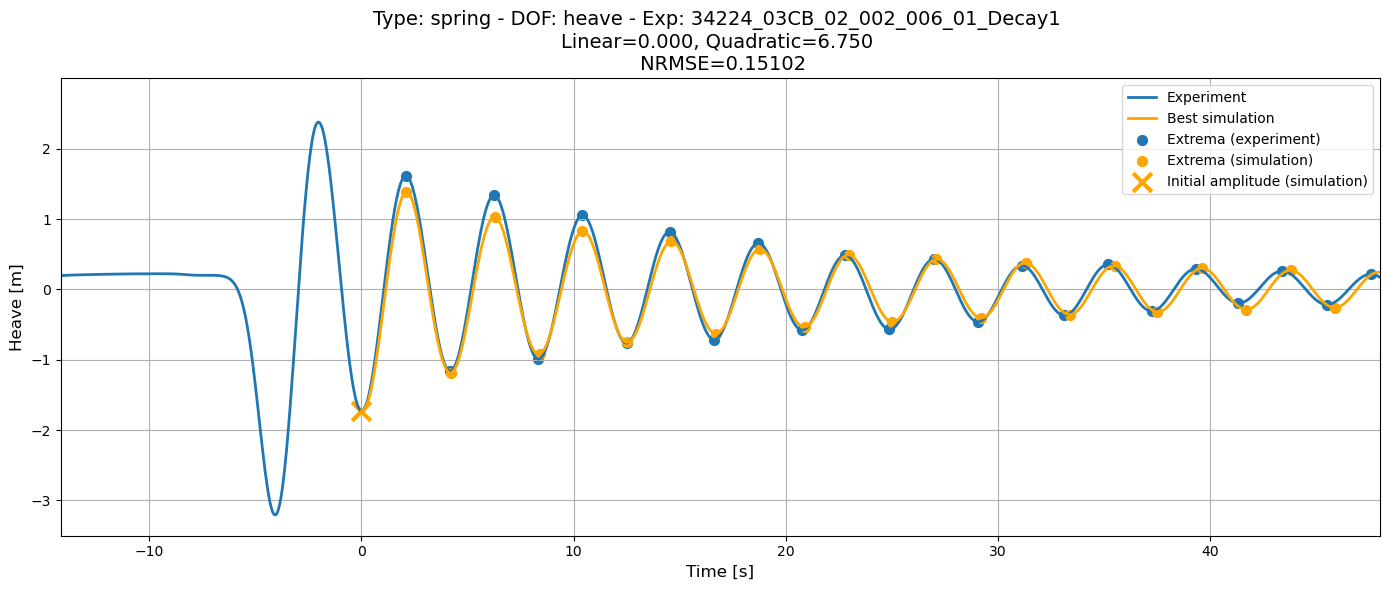

BEST -> lin=0.0000, quad=6.7500, score=0.151018

Experiment: 34224_03CB_02_002_006_01_Decay2.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=0.822060 (peaks=0.767012, troughs=0.877108)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=0.691629 (peaks=0.642995, troughs=0.740263)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=0.581395 (peaks=0.537806, troughs=0.624983)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=0.487061 (peaks=0.447717, troughs=0.526405)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.405970 (peaks=0.370459, troughs=0.441481)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.335981 (peaks=0.304000, troughs=0.367962)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.275904 (peaks=0.247384, troughs=0.304424)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.228567 (peaks=0.207087, troughs=0.250046)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.187535 (peaks=0.170371, troughs=0.204698)
[mid       1/9] lin(f

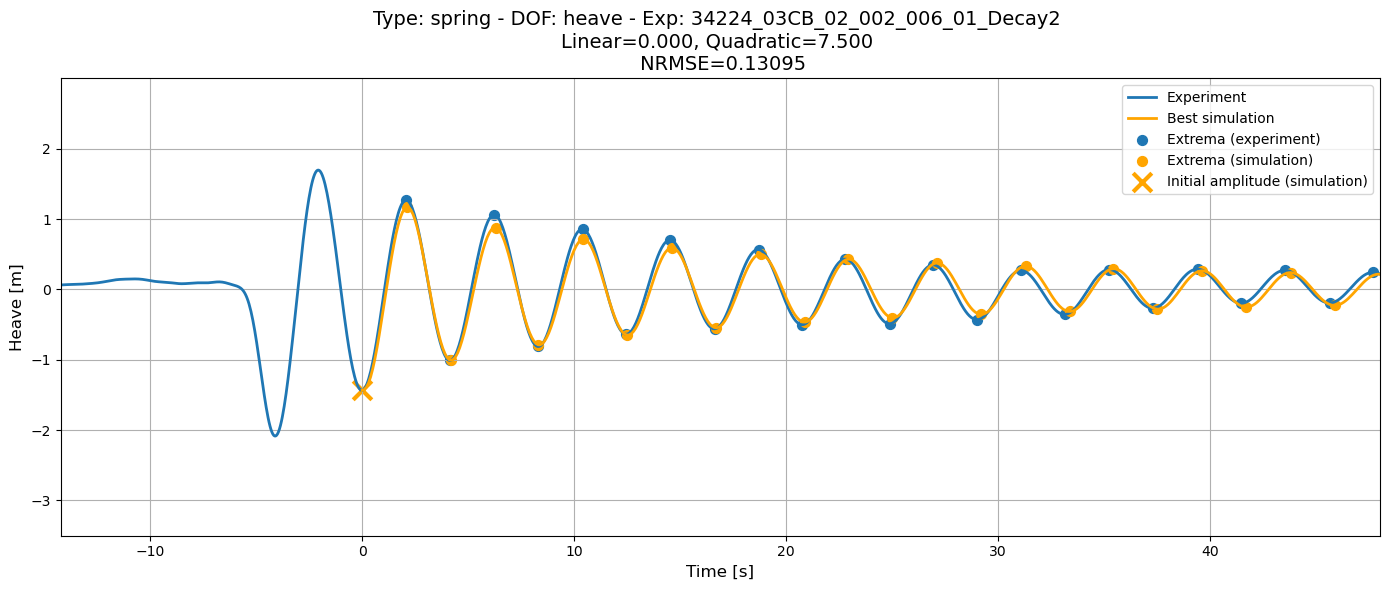

BEST -> lin=0.0000, quad=7.5000, score=0.130952

Experiment: 34224_03CB_02_002_007_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=0.924620 (peaks=0.892506, troughs=0.956734)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=0.766895 (peaks=0.739686, troughs=0.794104)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=0.636100 (peaks=0.612876, troughs=0.659325)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=0.526184 (peaks=0.506372, troughs=0.545996)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.432925 (peaks=0.416161, troughs=0.449688)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.358358 (peaks=0.349291, troughs=0.367425)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.291039 (peaks=0.284707, troughs=0.297371)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.234709 (peaks=0.230812, troughs=0.238606)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.189442 (peaks=0.187874, troughs=0.191010)
[mid       1/9] lin(f

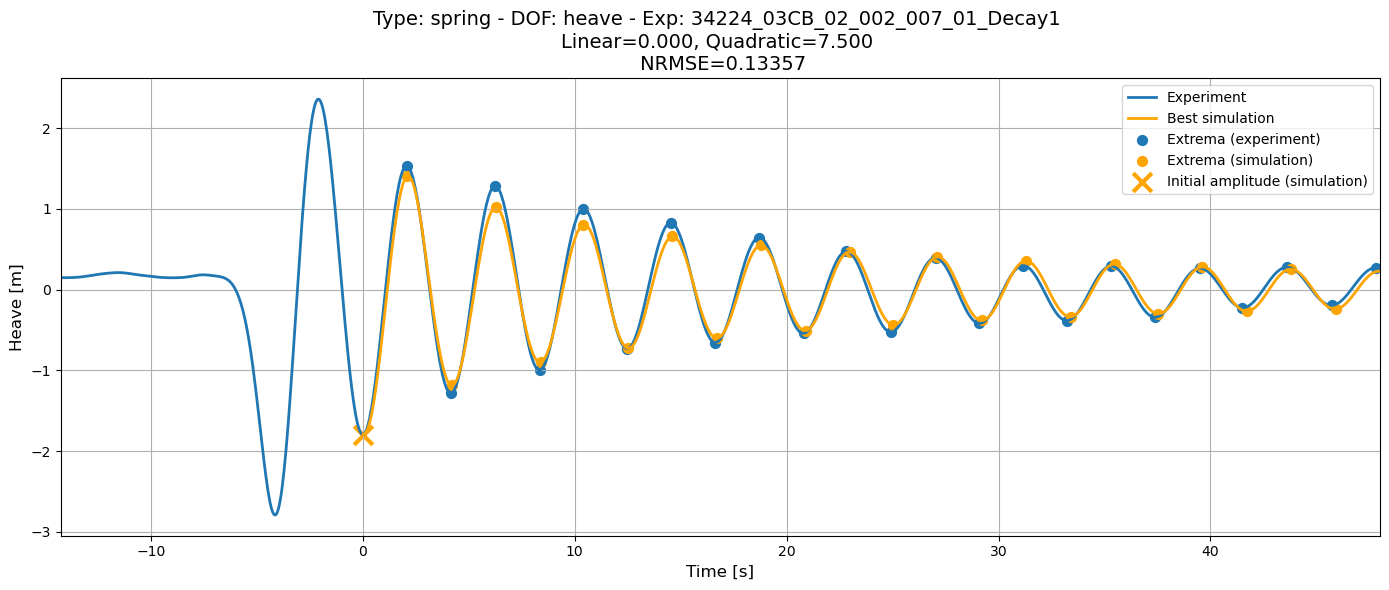

BEST -> lin=0.0000, quad=7.5000, score=0.133568

Experiment: 34224_03CB_02_002_008_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=1.649083 (peaks=1.675725, troughs=1.622441)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=1.387352 (peaks=1.413431, troughs=1.361272)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=1.177181 (peaks=1.202649, troughs=1.151714)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=1.004792 (peaks=1.029466, troughs=0.980118)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.817360 (peaks=0.796911, troughs=0.837809)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.702088 (peaks=0.685548, troughs=0.718627)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.604289 (peaks=0.591052, troughs=0.617525)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.521094 (peaks=0.510665, troughs=0.531524)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.450430 (peaks=0.442366, troughs=0.458495)
[mid       1/9] lin(f

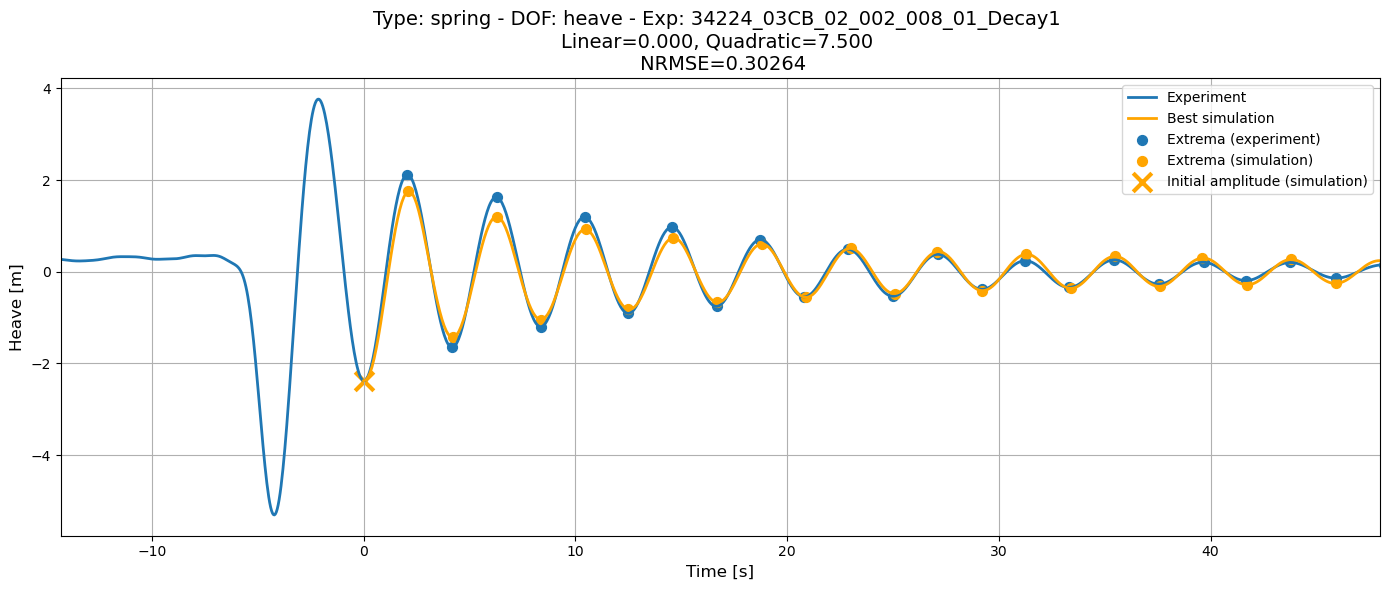

BEST -> lin=0.0000, quad=7.5000, score=0.302641

START: construction=fixedwith, dof=heave, n=4

Experiment: 34224_03CB_02_003_007_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=0.982511 (peaks=1.379136, troughs=0.585887)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=0.880339 (peaks=1.269224, troughs=0.491455)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=0.790204 (peaks=1.172578, troughs=0.407830)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=0.710266 (peaks=1.086885, troughs=0.333647)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.639092 (peaks=1.010204, troughs=0.267980)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.575834 (peaks=0.941411, troughs=0.210257)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.520194 (peaks=0.879394, troughs=0.160994)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.472734 (peaks=0.823161, troughs=0.122308)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.435405 (peaks=0.

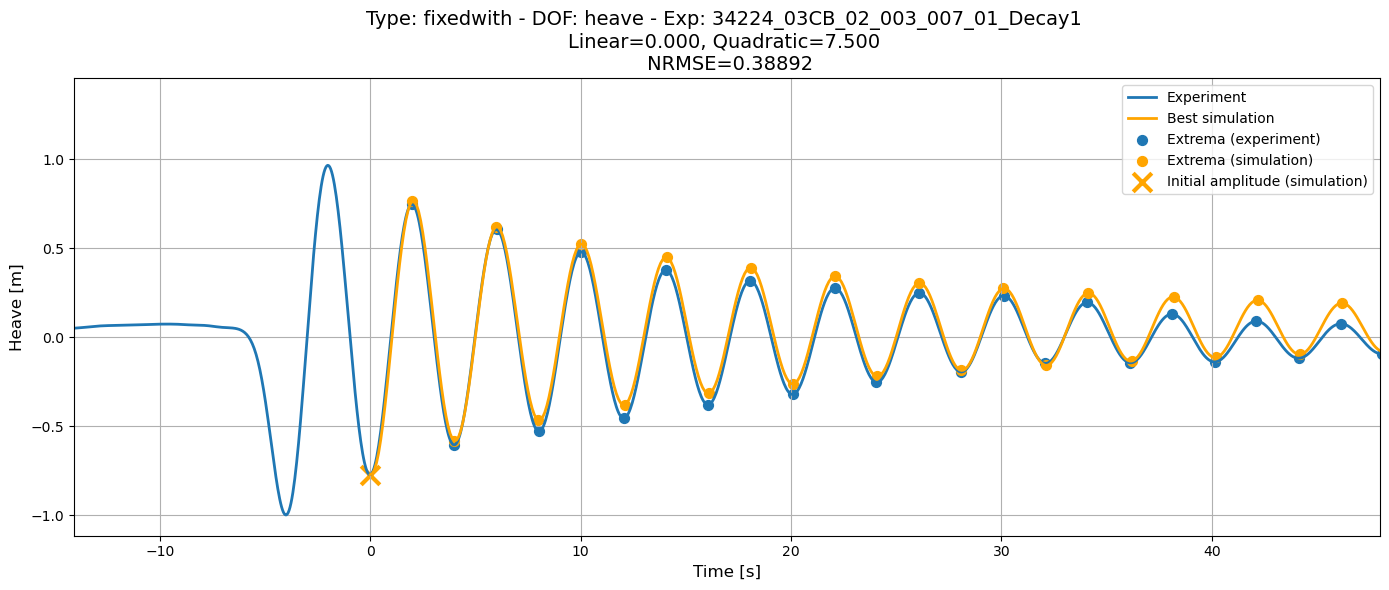

BEST -> lin=0.0000, quad=7.5000, score=0.388920

Experiment: 34224_03CB_02_003_008_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=0.680419 (peaks=0.851469, troughs=0.509370)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=0.543792 (peaks=0.704032, troughs=0.383553)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=0.433363 (peaks=0.582833, troughs=0.283892)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=0.344955 (peaks=0.481539, troughs=0.208371)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.278116 (peaks=0.396358, troughs=0.159874)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.233962 (peaks=0.324111, troughs=0.143813)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.209994 (peaks=0.263175, troughs=0.156813)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.199151 (peaks=0.212610, troughs=0.185692)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.196225 (peaks=0.172398, troughs=0.220053)
[mid       1/9] lin(f

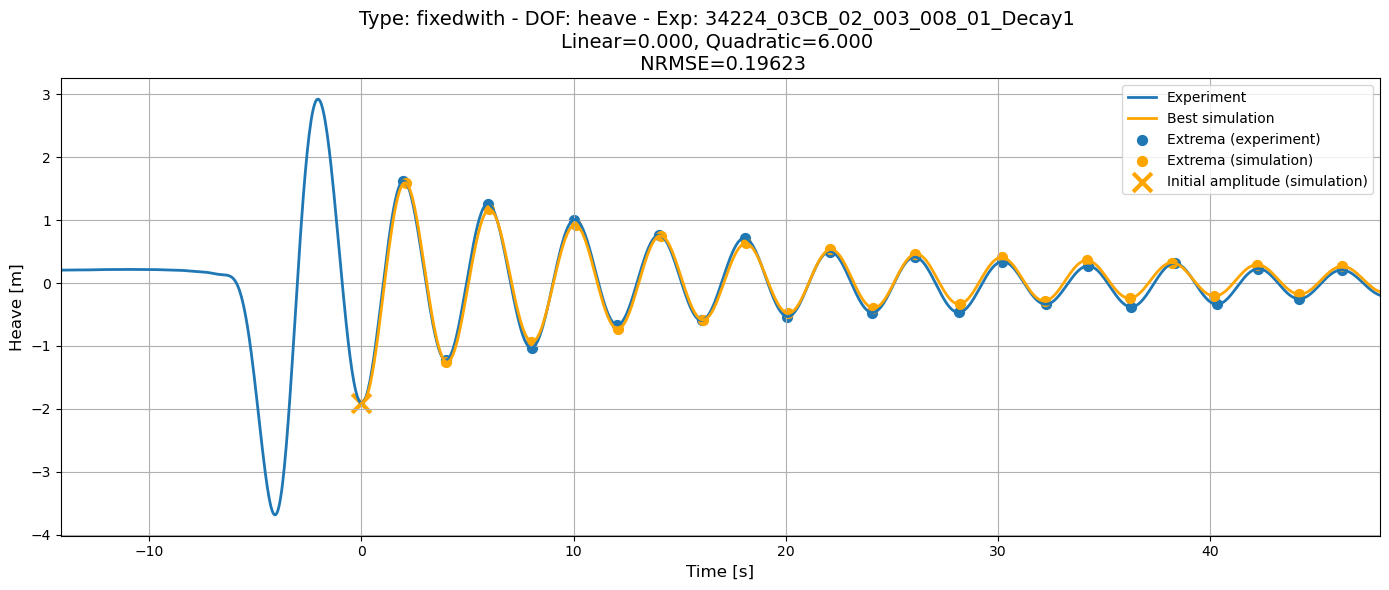

BEST -> lin=0.0000, quad=6.0000, score=0.196225

Experiment: 34224_03CB_02_003_009_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=1.833618 (peaks=1.793840, troughs=1.873396)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=1.557006 (peaks=1.547950, troughs=1.566063)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=1.333967 (peaks=1.348160, troughs=1.319773)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=1.150690 (peaks=1.183158, troughs=1.118223)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.997594 (peaks=1.044376, troughs=0.950812)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.868440 (peaks=0.926625, troughs=0.810254)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.758480 (peaks=0.825442, troughs=0.691517)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.664512 (peaks=0.737933, troughs=0.591092)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.584261 (peaks=0.661897, troughs=0.506626)
[mid       1/9] lin(f

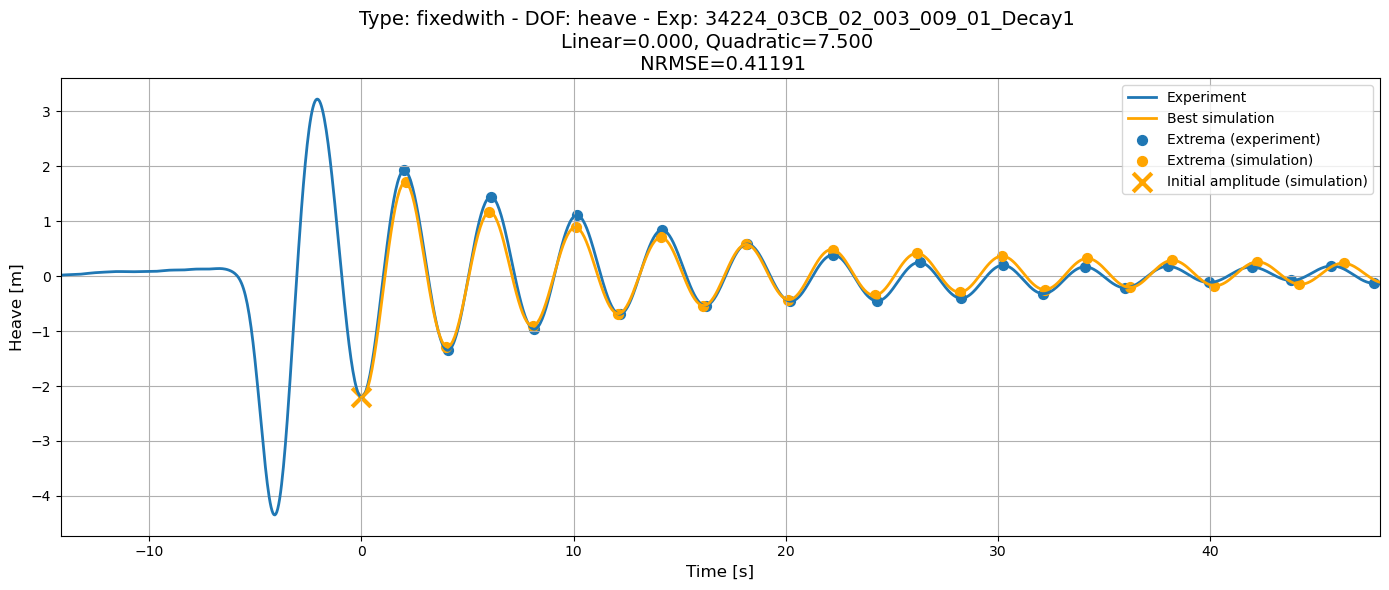

BEST -> lin=0.0000, quad=7.5000, score=0.411911

Experiment: 34224_03CB_02_003_010_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=1.648576 (peaks=1.634108, troughs=1.663044)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=1.393162 (peaks=1.402256, troughs=1.384068)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=1.186941 (peaks=1.214140, troughs=1.159743)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=1.017222 (peaks=1.058610, troughs=0.975835)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.875458 (peaks=0.927898, troughs=0.823019)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.755880 (peaks=0.816839, troughs=0.694922)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.654325 (peaks=0.721479, troughs=0.587172)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.567920 (peaks=0.638991, troughs=0.496848)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.494775 (peaks=0.567387, troughs=0.422164)
[mid       1/9] lin(f

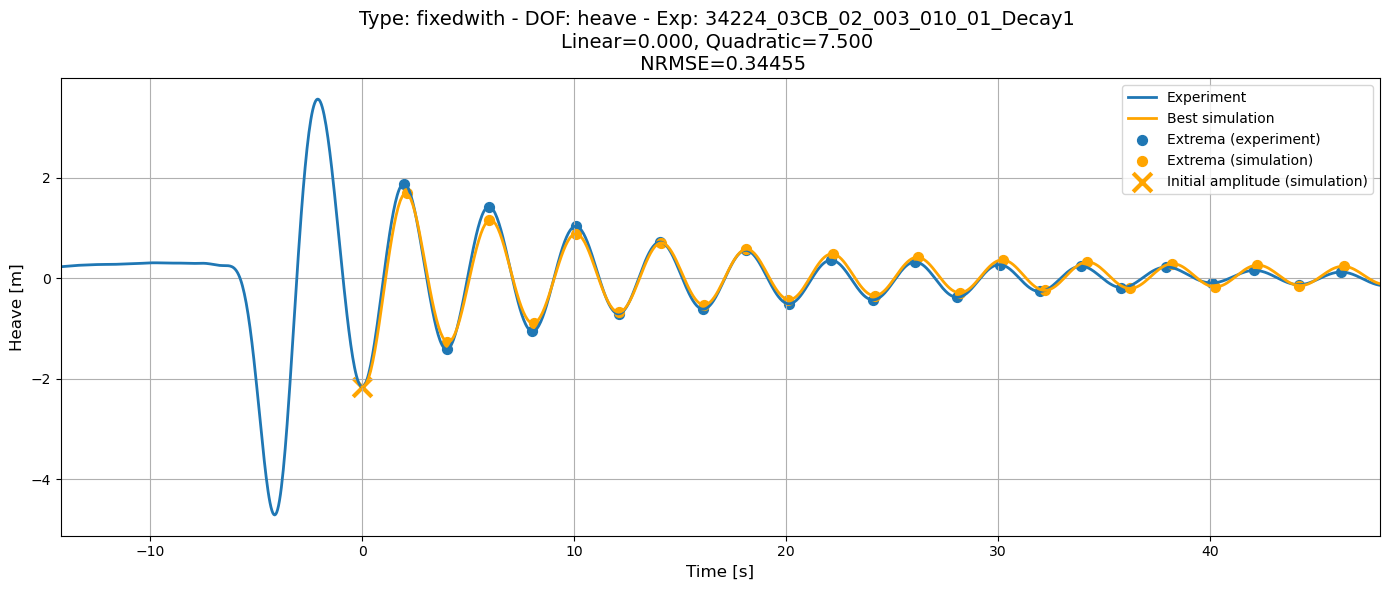

BEST -> lin=0.0000, quad=7.5000, score=0.344551

START: construction=fixedwithout, dof=heave, n=4

Experiment: 34224_03CB_02_004_009_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=0.281709 (peaks=0.389544, troughs=0.173873)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=0.272604 (peaks=0.331990, troughs=0.213217)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=0.268560 (peaks=0.283431, troughs=0.253689)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=0.267767 (peaks=0.243009, troughs=0.292524)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.269638 (peaks=0.210382, troughs=0.328895)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.274073 (peaks=0.185550, troughs=0.362595)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.281163 (peaks=0.168531, troughs=0.393795)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.290902 (peaks=0.159157, troughs=0.422647)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.303048 (peaks

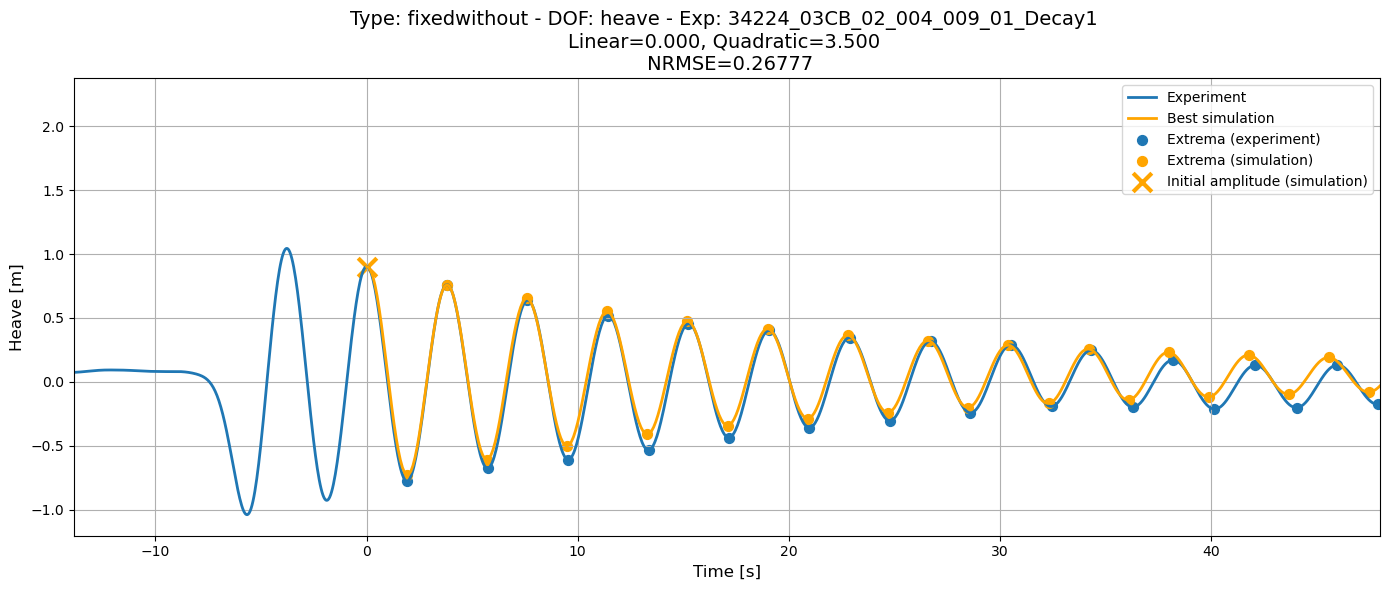

BEST -> lin=0.0000, quad=3.5000, score=0.267767

Experiment: 34224_03CB_02_004_010_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=0.136323 (peaks=0.068102, troughs=0.204545)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=0.164200 (peaks=0.059759, troughs=0.268642)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=0.218250 (peaks=0.110588, troughs=0.325912)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=0.269141 (peaks=0.162212, troughs=0.376069)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.314104 (peaks=0.208187, troughs=0.420022)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.353716 (peaks=0.248682, troughs=0.458751)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.388807 (peaks=0.284491, troughs=0.493123)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.420096 (peaks=0.316354, troughs=0.523837)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.448184 (peaks=0.344901, troughs=0.551468)
[mid       1/9] lin(f

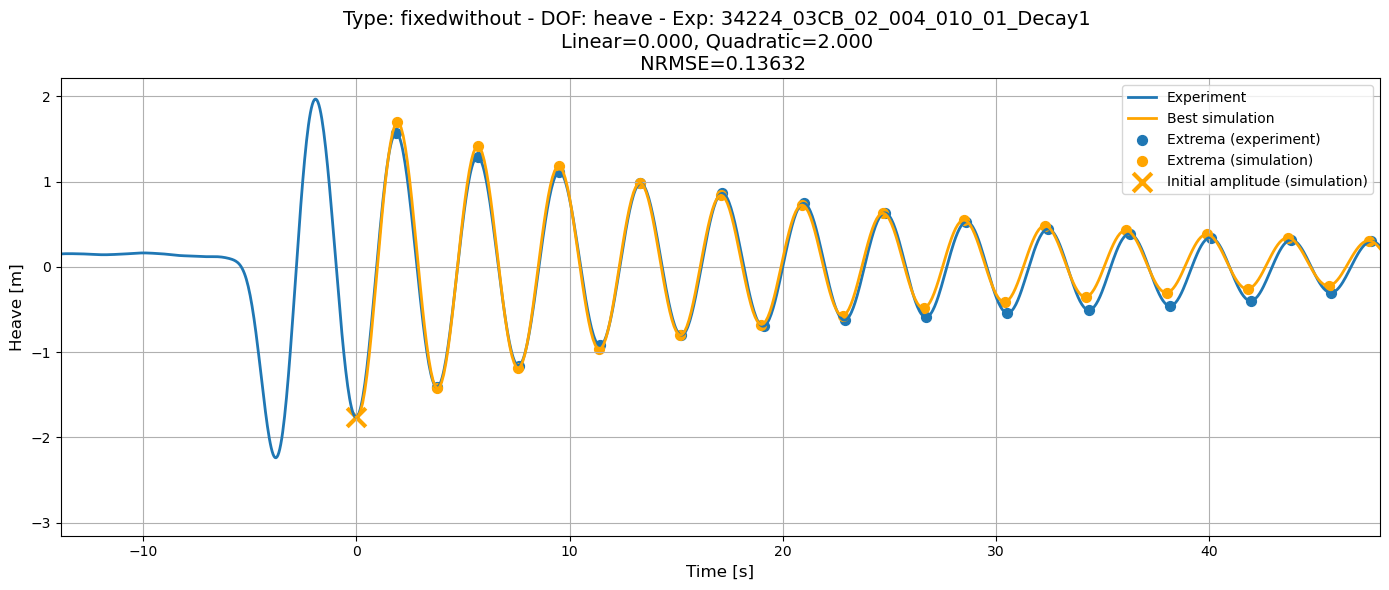

BEST -> lin=0.0000, quad=2.0000, score=0.136323

Experiment: 34224_03CB_02_004_011_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=0.114675 (peaks=0.124314, troughs=0.105036)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=0.123543 (peaks=0.066245, troughs=0.180841)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=0.186055 (peaks=0.111904, troughs=0.260207)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=0.251453 (peaks=0.174229, troughs=0.328677)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.308528 (peaks=0.230093, troughs=0.386964)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.357417 (peaks=0.278300, troughs=0.436533)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.399383 (peaks=0.319735, troughs=0.479032)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.435907 (peaks=0.355849, troughs=0.515966)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.468180 (peaks=0.387772, troughs=0.548588)
[mid       1/9] lin(f

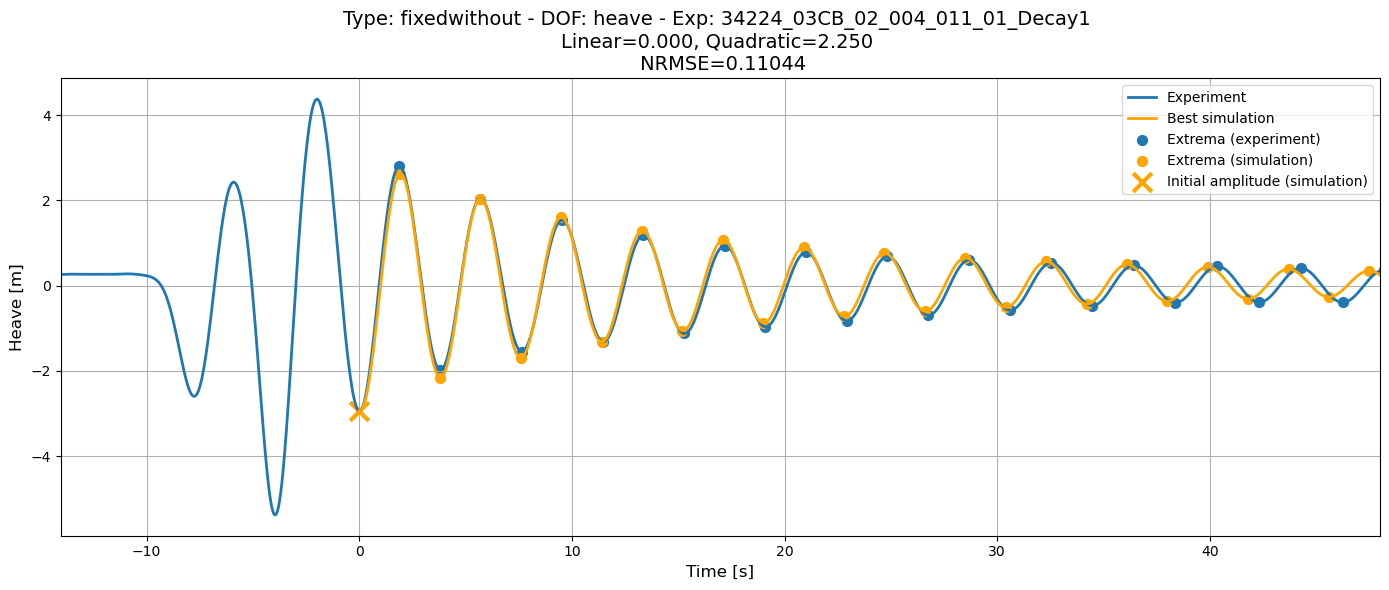

BEST -> lin=0.0000, quad=2.2500, score=0.110444

Experiment: 34224_03CB_02_004_012_01_Decay1.h5m
[coarse    1/9] lin(fixed)=0.0000, quad=2.0000, score=0.162032 (peaks=0.108290, troughs=0.215774)
[coarse    2/9] lin(fixed)=0.0000, quad=2.5000, score=0.185953 (peaks=0.093683, troughs=0.278224)
[coarse    3/9] lin(fixed)=0.0000, quad=3.0000, score=0.223962 (peaks=0.115924, troughs=0.332000)
[coarse    4/9] lin(fixed)=0.0000, quad=3.5000, score=0.264797 (peaks=0.150832, troughs=0.378762)
[coarse    5/9] lin(fixed)=0.0000, quad=4.0000, score=0.303244 (peaks=0.186717, troughs=0.419771)
[coarse    6/9] lin(fixed)=0.0000, quad=4.5000, score=0.338303 (peaks=0.220513, troughs=0.456093)
[coarse    7/9] lin(fixed)=0.0000, quad=5.0000, score=0.370024 (peaks=0.251554, troughs=0.488495)
[coarse    8/9] lin(fixed)=0.0000, quad=5.5000, score=0.398758 (peaks=0.279898, troughs=0.517618)
[coarse    9/9] lin(fixed)=0.0000, quad=6.0000, score=0.424867 (peaks=0.305773, troughs=0.543961)
[mid       1/9] lin(f

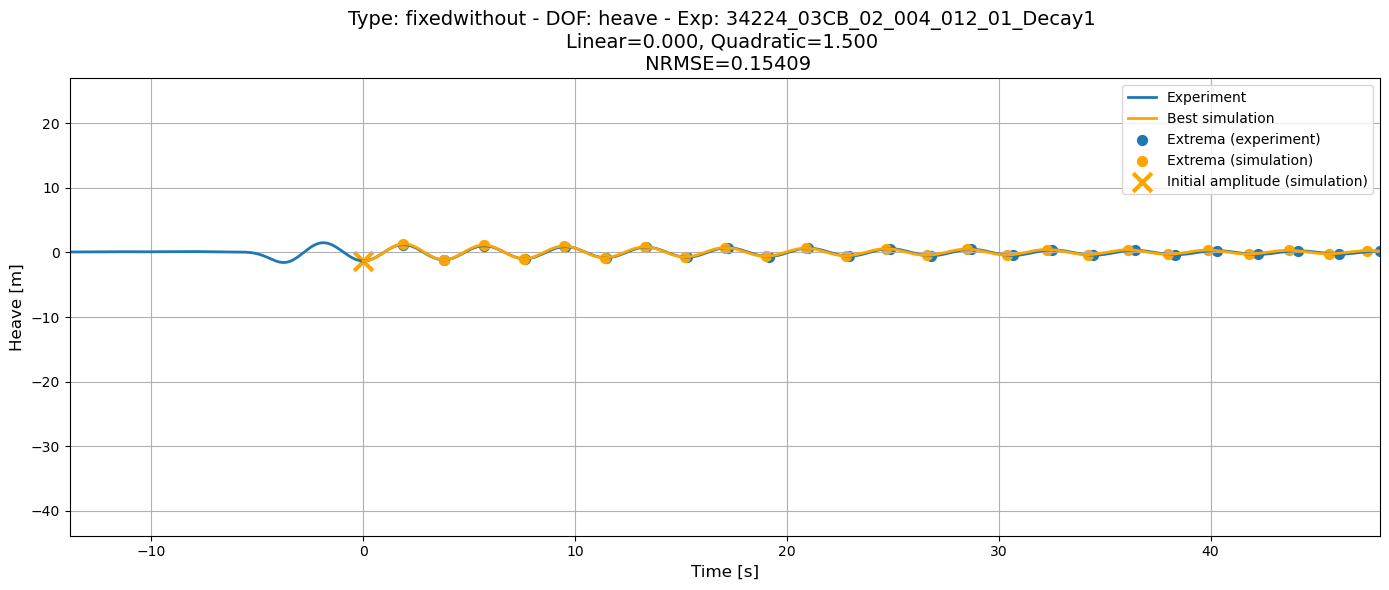

BEST -> lin=0.0000, quad=1.5000, score=0.154090

Klaar.
Aantal geslaagde calibraties: 12
Aantal fouten: 0


In [10]:
# ============================================================
# NOTEBOOK 10 - Alles runnen
# ============================================================
all_results = []
failed_cases = []

for construction, dof_dict in exp_paths.items():
    for dof, path_list in dof_dict.items():
        print("\n" + "=" * 80)
        print(f"START: construction={construction}, dof={dof}, n={len(path_list)}")
        print("=" * 80)

        for exp_path in path_list:
            print(f"\nExperiment: {exp_path.name}")

            try:
                exp_info = prepare_experiment(exp_path, dof)
                result = calibrate_single_experiment(exp_info, construction, dof, verbose=True)
                all_results.append(result)
                plot_best_fit(result, plots_dir)

                print(
                    f"BEST -> lin={result['best_lin']:.4f}, "
                    f"quad={result['best_quad']:.4f}, "
                    f"score={result['best_score']:.6f}"
                )

            except Exception as e:
                warnings.warn(f"Fout bij {exp_path}: {e}")
                failed_cases.append({
                    "construction": construction,
                    "dof": dof,
                    "exp_path": str(exp_path),
                    "error": str(e),
                })

print("\nKlaar.")
print(f"Aantal geslaagde calibraties: {len(all_results)}")
print(f"Aantal fouten: {len(failed_cases)}")


In [11]:
# ============================================================
# NOTEBOOK 11 - Resultaten naar DataFrame
# ============================================================
results_rows = []
for r in all_results:
    results_rows.append({
        "construction": r["construction"],
        "dof": r["dof"],
        "exp_path": r["exp_path"],
        "file_name": Path(r["exp_path"]).name,
        "intial amplitude": r["a_A1"],       
      
        "extremum_type": r["extremum_type"],
        "sim_init_time": r["sim_init_time"],
        "sim_init_amplitude": r["sim_init_amp"],
        "linear_damping": r["best_lin"],
        "quadratic_damping": r["best_quad"],
        "nmrse_total": r["best_score"],
        "nrmse_peaks": r["best_nrmse_peaks"],
        "nrmse_troughs": r["best_nrmse_troughs"],
    })

df_results = pd.DataFrame(results_rows)
df_failed = pd.DataFrame(failed_cases)

display(df_results.head())
if len(df_failed) > 0:
    display(df_failed.head())


,construction,dof,exp_path,file_name,intial amplitude,extremum_type,sim_init_time,sim_init_amplitude,linear_damping,quadratic_damping,nmrse_total,nrmse_peaks,nrmse_troughs
0,spring,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_006_01_Decay1.h5m,-3.206361,trough,0.0,-1.728647,0.0,6.75,0.151018,0.127804,0.174232
1,spring,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_006_01_Decay2.h5m,-2.084741,trough,0.0,-1.434860,0.0,7.50,0.130952,0.129740,0.132163
2,spring,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_007_01_Decay1.h5m,-2.790992,trough,0.0,-1.796261,0.0,7.50,0.133568,0.137469,0.129667
3,spring,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_008_01_Decay1.h5m,-5.307183,trough,0.0,-2.378943,0.0,7.50,0.302641,0.299579,0.305704
4,fixedwith,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_003_007_01_Decay1.h5m,-0.999335,trough,0.0,-0.772836,0.0,7.50,0.388920,0.643838,0.134002


In [12]:
# ============================================================
# Excel export - HEAVE
# ============================================================
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    df_dof = df_results[df_results["dof"] == "heave"].copy()
    df_dof = df_dof.sort_values(["construction", "file_name"])
    df_dof.to_excel(writer, sheet_name="heave", index=False)

    if len(df_failed) > 0:
        df_failed.to_excel(writer, sheet_name="failed_cases", index=False)

print(f"Excel opgeslagen naar:\n{excel_path}")
print(f"Plots opgeslagen in:\n{plots_dir}")


Excel opgeslagen naar:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_quadonly\calibrated_heave_decay_coefficients_quadonly.xlsx
Plots opgeslagen in:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_quadonly\plots
